In [1]:
using PhysicalConstants
using PhysicalConstants.CODATA2022: ħ, m_e, c_0
using Unitful
using Plots

In [2]:
function Kronig_Penney(E, ω, b, V₀; m_eff = 0.067, normalizado = false)
    
    a = ω + b
    
    # estas dos variables las añado para que el coseno de k₁ y k₂ no haga overflow
    mₑc² = ustrip(uconvert(u"eV", m_e*c_0^2))                 # en EV
    ħc = ustrip(uconvert(u"eV*nm", ħ*c_0))                    # en eV nm

    k₁ = @. sqrt(2 * m_eff * mₑc² * E) / ħc                   # en nm⁻¹
    k₂ = @. sqrt(Complex(2 * m_eff * mₑc² * (E - V₀))) / ħc   # en nm⁻¹
    
    # Valor de cos(ka), con esto vemos las bandas imponiendo que f este entre -1 y +1
    f = @. cos(k₁*ω)*cos(k₂*b) - ((k₁^2 + k₂^2) / (2 * k₁ * k₂)) * sin(k₁*ω)*sin(k₂*b)
    
    banda = real.(f)
    
    k_eff, E_eff = Calcular_k(E, banda, a, normalizado)
    
    return banda, k_eff, E_eff
end



function Calcular_k(E, band, a, normalizar)
    
    Es = []
    ks = []
    
    for i in 1:length(band)
        if (abs(band[i]) <= 1.0)
            push!(Es, E[i])
            if normalizar
                push!(ks, acos(band[i])/π)    # en unidades de π/a
            else
                push!(ks, acos(band[i])/a)    # k en nm⁻¹
            end
        end
    end
    
    return ks, Es
end
        

Calcular_k (generic function with 1 method)

In [ ]:
Energy = 0:0.001:1.0
Barrier_Potential = 0.4
Barrier_width = 2.0
Well_width = 6.0
banda, k_bandas, E_bandas = Kronig_Penney(Energy,Well_width,Barrier_width,Barrier_Potential, normalizado = true)

([NaN, 9.067428923824703, 8.870696474579333, 8.676515396513425, 8.48486228325798, 8.295713893640414, 8.109047150740505, 7.9248391409508745, 7.743067113041983, 7.563708477231593  …  -0.8902507894540186, -0.8872078748995946, -0.8841386937898054, -0.8810433937548662, -0.8779221228030272, -0.8747750293144575, -0.8716022620351405, -0.8684039700707897, -0.865180302880787, -0.8619314102721415], Any[0.07246379314110714, 0.14664267747727724, 0.19470312916262122, 0.2333997106274225, 0.26685560205124054, 0.29686548815034136, 0.3244046188435468, 0.35007433031852603, 0.3742777152809481, 0.3973018209353079  …  0.8494709883396389, 0.8473581101410496, 0.8452539684651756, 0.8431582480210005, 0.8410706513994403, 0.8389908977572401, 0.8369187216196735, 0.8348538717893722, 0.8327961103501565, 0.8307452117560863], Any[0.062, 0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07, 0.071  …  0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999, 1.0])

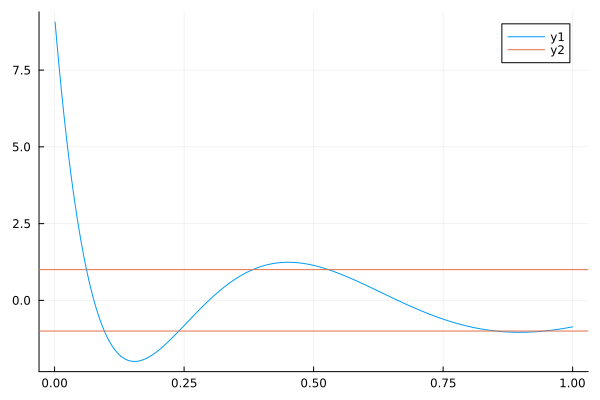

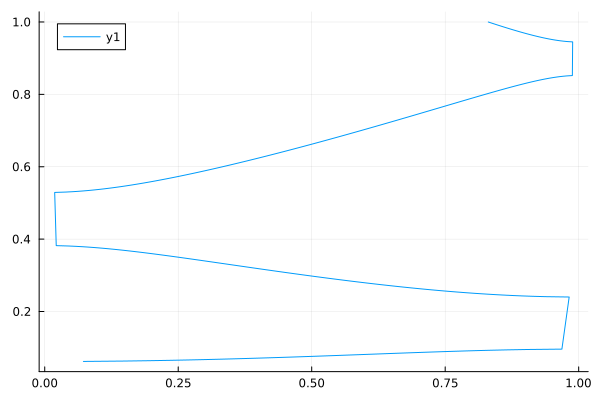

In [7]:
p1 = plot(Energy, banda)
hline!([1.0, -1.0])
p2 = plot(k_bandas,E_bandas)

display(p1)
display(p2)